In [1]:
import pandas as pd

df = pd.read_csv("../data/dataset.csv")

print(df.shape)
df.head()

(114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [3]:
df["track_genre"].value_counts().head(10)

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
anime          1000
black-metal    1000
bluegrass      1000
blues          1000
brazil         1000
Name: count, dtype: int64

In [4]:
df = df.drop(columns=[
    "Unnamed: 0",
    "track_id",
    "artists",
    "album_name",
    "track_name"
])

In [5]:
features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms"
]

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

In [7]:
genre_profiles = df_scaled.groupby("track_genre")[features].mean()

In [8]:
print(genre_profiles.shape)
genre_profiles.head()

(114, 10)


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
track_genre,,,,,,,,,,
acoustic,-0.099153,-0.819053,-0.236391,-0.391605,0.757565,-0.380270,-0.316784,-0.193031,-0.104650,-0.122391
afrobeat,0.592250,0.244224,0.093374,0.018223,-0.132473,0.314754,-0.152103,0.866123,-0.097888,0.189974
alt-rock,-0.186163,0.448420,0.411084,-0.279779,-0.579656,-0.329355,-0.017356,0.170455,0.082946,0.069217
alternative,-0.039605,0.312678,0.433495,-0.137626,-0.502494,-0.380842,-0.063960,0.082936,0.002821,-0.056040
ambient,-1.146316,-1.607062,-2.056424,-0.407541,1.389024,1.680393,-0.442647,-1.182481,-0.368093,0.084158


In [9]:
df["track_genre"].nunique()

114

In [10]:
sorted(df["track_genre"].unique())

['acoustic',
 'afrobeat',
 'alt-rock',
 'alternative',
 'ambient',
 'anime',
 'black-metal',
 'bluegrass',
 'blues',
 'brazil',
 'breakbeat',
 'british',
 'cantopop',
 'chicago-house',
 'children',
 'chill',
 'classical',
 'club',
 'comedy',
 'country',
 'dance',
 'dancehall',
 'death-metal',
 'deep-house',
 'detroit-techno',
 'disco',
 'disney',
 'drum-and-bass',
 'dub',
 'dubstep',
 'edm',
 'electro',
 'electronic',
 'emo',
 'folk',
 'forro',
 'french',
 'funk',
 'garage',
 'german',
 'gospel',
 'goth',
 'grindcore',
 'groove',
 'grunge',
 'guitar',
 'happy',
 'hard-rock',
 'hardcore',
 'hardstyle',
 'heavy-metal',
 'hip-hop',
 'honky-tonk',
 'house',
 'idm',
 'indian',
 'indie',
 'indie-pop',
 'industrial',
 'iranian',
 'j-dance',
 'j-idol',
 'j-pop',
 'j-rock',
 'jazz',
 'k-pop',
 'kids',
 'latin',
 'latino',
 'malay',
 'mandopop',
 'metal',
 'metalcore',
 'minimal-techno',
 'mpb',
 'new-age',
 'opera',
 'pagode',
 'party',
 'piano',
 'pop',
 'pop-film',
 'power-pop',
 'progressive

In [11]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(genre_profiles)

In [12]:
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=genre_profiles.index,
    columns=genre_profiles.index
)

In [13]:
similarity_df.head()

track_genre,acoustic,afrobeat,alt-rock,alternative,ambient,anime,black-metal,bluegrass,blues,brazil,...,spanish,study,swedish,synth-pop,tango,techno,trance,trip-hop,turkish,world-music
track_genre,,,,,,,,,,,,,,,,,,,,,
acoustic,1.000000,-0.413039,-0.530429,-0.466190,0.563834,-0.422885,-0.474959,0.649978,0.560971,0.021504,...,-0.349368,0.207267,0.385646,-0.386877,0.796076,-0.486264,-0.713643,-0.287162,0.313607,0.350928
afrobeat,-0.413039,1.000000,0.140516,0.109717,-0.409065,-0.153933,-0.360420,0.090850,0.265577,-0.184061,...,0.403677,0.121395,0.162467,0.626964,-0.134929,0.287151,0.016272,0.495370,-0.008381,-0.754285
alt-rock,-0.530429,0.140516,1.000000,0.950571,-0.744192,0.092852,0.358247,-0.389837,-0.027770,0.167556,...,0.681043,-0.749119,0.313803,0.694357,-0.722322,0.054647,0.369276,-0.225517,-0.103516,-0.015691
alternative,-0.466190,0.109717,0.950571,1.000000,-0.830683,0.033213,0.198331,-0.490802,0.008100,0.166952,...,0.768685,-0.718086,0.445530,0.651574,-0.688451,-0.028845,0.282797,-0.317546,0.157208,-0.122979
ambient,0.563834,-0.409065,-0.744192,-0.830683,1.000000,0.214218,0.112164,0.397633,-0.078260,-0.325256,...,-0.955926,0.637296,-0.461501,-0.633179,0.542173,0.063803,-0.168712,0.277005,-0.318035,0.489035


In [14]:
similarity_df.loc["rock"].sort_values(ascending=False).head(10)

track_genre
rock           1.000000
j-pop          0.913713
alternative    0.862136
alt-rock       0.859534
j-rock         0.836194
punk           0.822775
punk-rock      0.807574
country        0.783632
power-pop      0.776186
hard-rock      0.724531
Name: rock, dtype: float64

In [15]:
import networkx as nx

G = nx.Graph()

genres = similarity_df.index

threshold = 0.7

for i in range(len(genres)):
    for j in range(i + 1, len(genres)):
        g1 = genres[i]
        g2 = genres[j]
        sim = similarity_df.loc[g1, g2]
        
        if sim > threshold:
            G.add_edge(g1, g2, weight=sim)

In [16]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 113
Edges: 636


In [17]:
degree_dict = dict(G.degree())
sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]

[('industrial', 25),
 ('alternative', 23),
 ('metal', 22),
 ('metalcore', 22),
 ('alt-rock', 21),
 ('groove', 21),
 ('heavy-metal', 21),
 ('j-idol', 20),
 ('punk', 20),
 ('punk-rock', 20)]

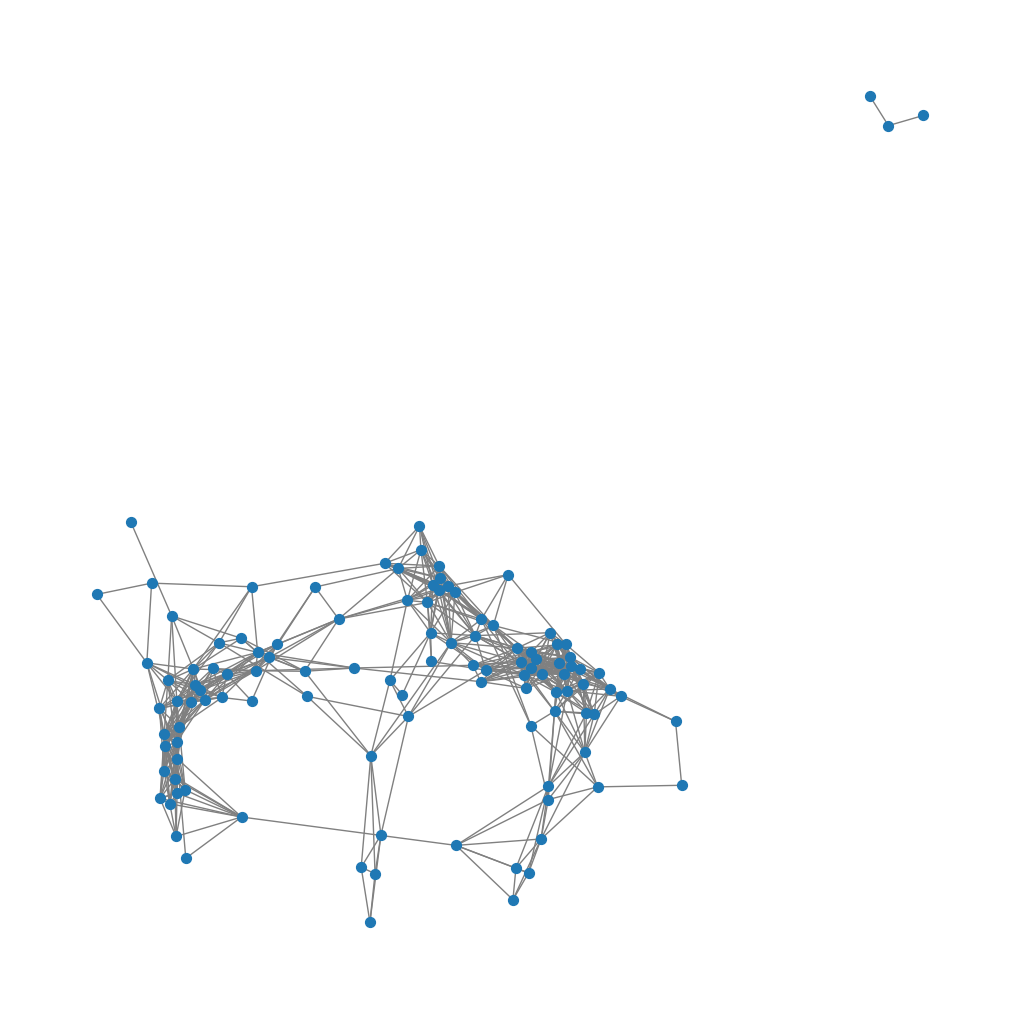

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
pos = nx.spring_layout(G, seed=42)

nx.draw(G, pos, node_size=50, edge_color='gray', with_labels=False)
plt.show()

In [19]:
degree_centrality = nx.degree_centrality(G)

sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

[('industrial', 0.2232142857142857),
 ('alternative', 0.20535714285714285),
 ('metal', 0.19642857142857142),
 ('metalcore', 0.19642857142857142),
 ('alt-rock', 0.1875),
 ('groove', 0.1875),
 ('heavy-metal', 0.1875),
 ('j-idol', 0.17857142857142855),
 ('punk', 0.17857142857142855),
 ('punk-rock', 0.17857142857142855)]

In [20]:
betweenness = nx.betweenness_centrality(G)

sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]

[('minimal-techno', 0.11521128717048072),
 ('idm', 0.11186490107869654),
 ('country', 0.09543815546739166),
 ('pop', 0.08685976048336463),
 ('breakbeat', 0.08550047877968212),
 ('honky-tonk', 0.07065435448597368),
 ('spanish', 0.06965031155029015),
 ('indie', 0.06873019756139584),
 ('r-n-b', 0.06620678490227576),
 ('soul', 0.06456988249215942)]

In [21]:
clustering = nx.clustering(G)

sorted(clustering.items(), key=lambda x: x[1], reverse=True)[:10]

[('afrobeat', 1.0),
 ('iranian', 1.0),
 ('trip-hop', 1.0),
 ('french', 1.0),
 ('j-dance', 1.0),
 ('pop-film', 1.0),
 ('study', 1.0),
 ('mpb', 1.0),
 ('mandopop', 0.9523809523809523),
 ('garage', 0.9393939393939394)]

In [22]:
import community as community_louvain

In [23]:
# NOTE ON REPRODUCIBILITY:
# The Louvain community detection algorithm is stochastic, meaning that
# different runs may yield different numbers of communities (e.g., 6 or 7)
# due to internal randomization in the optimization process.
#
# To ensure reproducibility of results and consistency across all analyses
# (tables, plots, and Gephi visualizations), a fixed random_state is used.
#
# In this study, random_state=3 is selected because it produces a stable
# partition with 6 communities, which is used consistently throughout
# the paper.

In [24]:
for seed in range(100):
    temp_partition = community_louvain.best_partition(
        G,
        weight="weight",
        random_state=seed
    )
    
    n_communities = len(set(temp_partition.values()))
    
    if n_communities == 6:
        print("Seed giving 6 communities:", seed)
        break

Seed giving 6 communities: 3


In [25]:
partition = community_louvain.best_partition(
    G,
    weight="weight",
    random_state=3
)

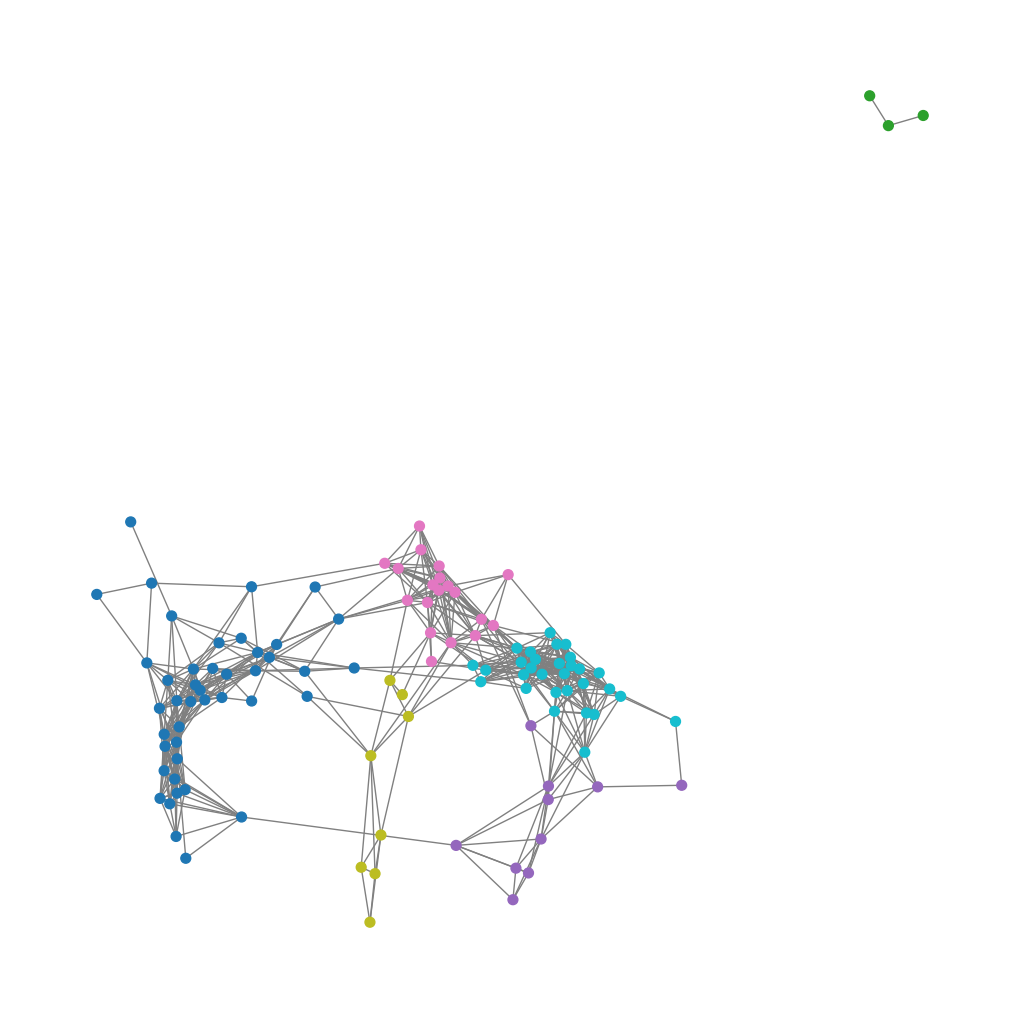

In [26]:
plt.figure(figsize=(10,10))

pos = nx.spring_layout(G, seed=42)

colors = [partition[node] for node in G.nodes()]

nx.draw(
    G,
    pos,
    node_color=colors,
    cmap=plt.cm.tab10,
    node_size=50,
    edge_color='gray',
    with_labels=False
)

plt.show()

In [27]:
community_dict = {}

for genre, comm in partition.items():
    community_dict.setdefault(comm, []).append(genre)

community_summary = []

for comm, genres in community_dict.items():
    community_summary.append({
        "community": comm,
        "size": len(genres),
        "genres": ", ".join(sorted(genres))
    })

community_summary_df = pd.DataFrame(community_summary).sort_values("size", ascending=False)
community_summary_df

,community,size,genres
0,0,43,"acoustic, ambient, bluegrass, blues, british, ..."
3,5,30,"alt-rock, alternative, black-metal, death-meta..."
2,3,19,"dance, dancehall, disco, edm, electro, emo, fu..."
4,2,10,"anime, breakbeat, chicago-house, club, deep-ho..."
1,4,8,"afrobeat, forro, mpb, pagode, r-n-b, salsa, sa..."
5,1,3,"brazil, gospel, world-music"


In [28]:
community_profile = genre_profiles.copy()
community_profile["community"] = community_profile.index.map(partition)

community_feature_means = community_profile.groupby("community")[features].mean()
community_feature_means.round(2)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
community,,,,,,,,,,
0.0,-0.20,-0.69,-0.57,-0.17,0.67,0.13,-0.15,-0.13,-0.18,-0.13
1.0,-0.48,-0.26,0.04,-0.24,0.06,-0.39,0.36,-0.49,0.03,0.62
2.0,0.59,0.30,0.01,-0.08,-0.58,0.90,-0.20,-0.19,0.08,0.56
3.0,0.70,0.28,0.44,0.23,-0.37,-0.43,-0.13,0.41,-0.05,-0.18
4.0,0.28,0.20,0.21,-0.14,0.33,-0.38,0.65,0.81,0.08,-0.00
5.0,-0.37,0.68,0.49,-0.03,-0.67,-0.05,0.08,-0.17,0.27,0.06


In [29]:
import pandas as pd

# Community → color mapping (senin legend'e göre)
community_colors = {
    0: "PURPLE",
    5: "GREEN",
    3: "CYAN",
    2: "ORANGE",
    4: "DARK GREEN",
    1: "PINK"
}

# rename index
table = community_feature_means.copy()
table["community_color"] = table.index.map(community_colors)

# index'i kaldır, color'ı öne al
table = table.reset_index(drop=True)
cols = ["community_color"] + [c for c in table.columns if c != "community_color"]
table = table[cols]

# round (zaten yaptın ama garanti)
table = table.round(2)
table.columns = [
    "Community",
    "Danceability", "Energy", "Loudness", "Speechiness",
    "Acousticness", "Instrumentalness", "Liveness",
    "Valence", "Tempo", "Duration"
]
table

,Community,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration
0,PURPLE,-0.20,-0.69,-0.57,-0.17,0.67,0.13,-0.15,-0.13,-0.18,-0.13
1,PINK,-0.48,-0.26,0.04,-0.24,0.06,-0.39,0.36,-0.49,0.03,0.62
2,ORANGE,0.59,0.30,0.01,-0.08,-0.58,0.90,-0.20,-0.19,0.08,0.56
3,CYAN,0.70,0.28,0.44,0.23,-0.37,-0.43,-0.13,0.41,-0.05,-0.18
4,DARK GREEN,0.28,0.20,0.21,-0.14,0.33,-0.38,0.65,0.81,0.08,-0.00
5,GREEN,-0.37,0.68,0.49,-0.03,-0.67,-0.05,0.08,-0.17,0.27,0.06


In [30]:
modularity = community_louvain.modularity(partition, G)
modularity

np.float64(0.6119513149398697)

In [31]:
genre_popularity = df.groupby("track_genre")["popularity"].mean()

In [32]:
analysis_df = pd.DataFrame({
    "degree": pd.Series(degree_centrality),
    "betweenness": pd.Series(betweenness),
    "clustering": pd.Series(clustering),
    "popularity": genre_popularity
})

In [33]:
analysis_df.head()

,degree,betweenness,clustering,popularity
acoustic,0.151786,0.020235,0.602941,42.483
afrobeat,0.017857,0.000000,1.000000,24.399
alt-rock,0.187500,0.021565,0.619048,33.943
alternative,0.205357,0.050425,0.521739,24.337
ambient,0.107143,0.005245,0.818182,44.191


In [34]:
analysis_df.corr()

,degree,betweenness,clustering,popularity
degree,1.000000,0.209455,0.101023,-0.150464
betweenness,0.209455,1.000000,-0.338081,-0.190445
clustering,0.101023,-0.338081,1.000000,-0.151058
popularity,-0.150464,-0.190445,-0.151058,1.000000


In [35]:
analysis_df[["degree", "betweenness", "popularity"]].corr()

,degree,betweenness,popularity
degree,1.000000,0.209455,-0.150464
betweenness,0.209455,1.000000,-0.190445
popularity,-0.150464,-0.190445,1.000000


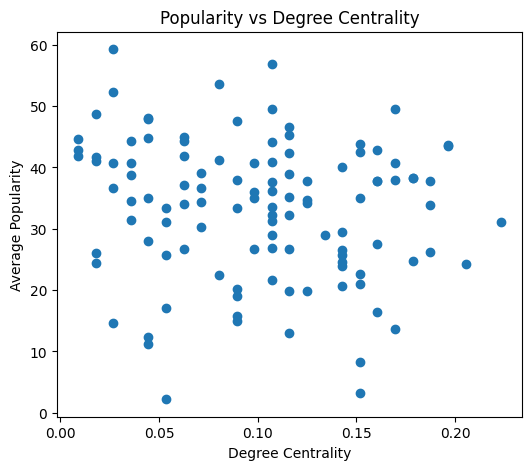

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(analysis_df["degree"], analysis_df["popularity"])

plt.xlabel("Degree Centrality")
plt.ylabel("Average Popularity")
plt.title("Popularity vs Degree Centrality")

plt.show()

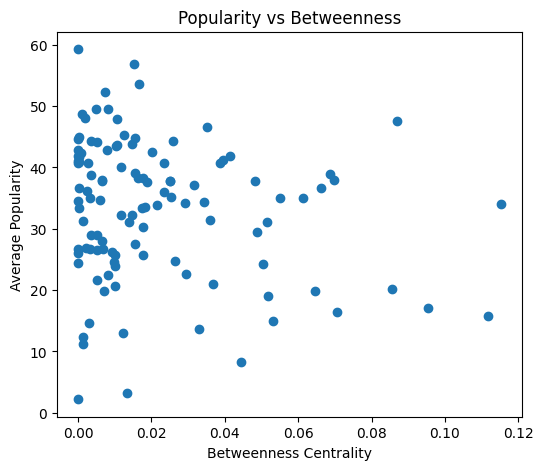

In [37]:
plt.figure(figsize=(6,5))

plt.scatter(analysis_df["betweenness"], analysis_df["popularity"])

plt.xlabel("Betweenness Centrality")
plt.ylabel("Average Popularity")
plt.title("Popularity vs Betweenness")

plt.show()

In [38]:
analysis_df.sort_values("popularity", ascending=False).head(10)
analysis_df.sort_values("popularity").head(10)

,degree,betweenness,clustering,popularity
iranian,0.053571,0.000000,1.000000,2.210
romance,0.151786,0.013361,0.639706,3.245
latin,0.151786,0.044279,0.588235,8.297
detroit-techno,0.044643,0.001231,0.900000,11.174
chicago-house,0.044643,0.001231,0.900000,12.339
classical,0.116071,0.012213,0.769231,13.055
jazz,0.169643,0.033089,0.526316,13.628
grindcore,0.026786,0.003044,0.333333,14.625
kids,0.089286,0.053156,0.755556,14.888
idm,0.089286,0.111865,0.600000,15.766


In [39]:
for node in G.nodes():
    G.nodes[node]["community"] = int(partition[node])

nx.write_gexf(G, "../gephi/genre_network_fixed_communities.gexf")

<Axes: xlabel='community'>

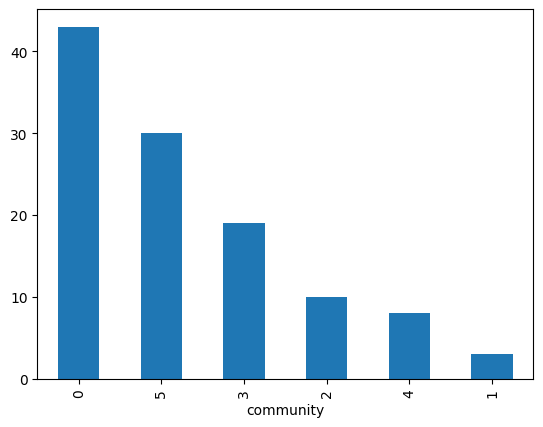

In [40]:
community_sizes = community_summary_df.set_index("community")["size"]
community_sizes.plot(kind="bar")

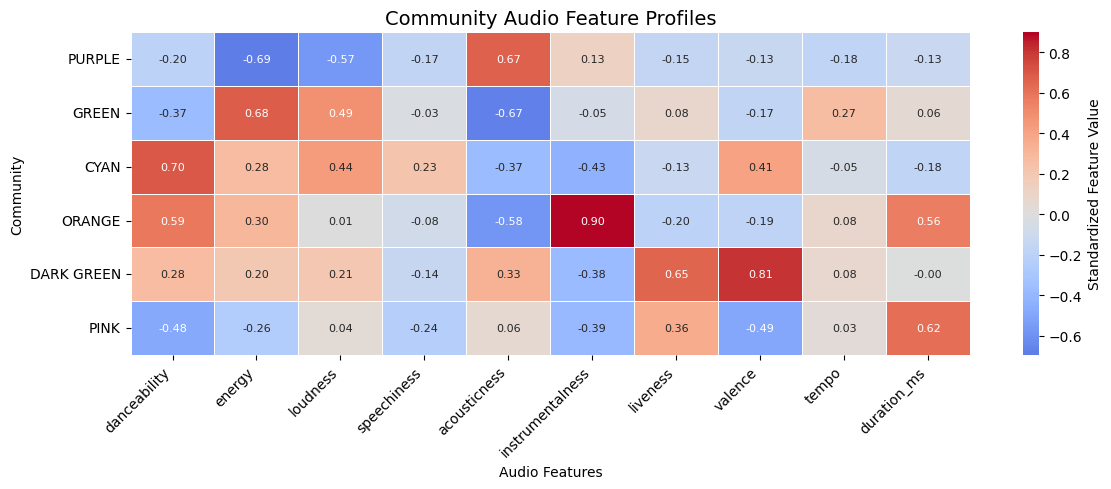

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Community ID -> color name mapping
community_labels = {
    0: "PURPLE",
    5: "GREEN",
    3: "CYAN",
    2: "ORANGE",
    4: "DARK GREEN",
    1: "PINK"
}

# Prepare heatmap dataframe
heatmap_df = community_feature_means.copy()
heatmap_df.index = heatmap_df.index.astype(int)
heatmap_df = heatmap_df.rename(index=community_labels)

# Optional: order rows according to Figure 5 legend
row_order = ["PURPLE", "GREEN", "CYAN", "ORANGE", "DARK GREEN", "PINK"]
heatmap_df = heatmap_df.loc[row_order]

plt.figure(figsize=(12, 5))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Standardized Feature Value"},
    annot_kws={"size": 8}
)

plt.title("Community Audio Feature Profiles", fontsize=14)
plt.xlabel("Audio Features")
plt.ylabel("Community")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("../outputs/community_feature_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [42]:
import networkx as nx

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)
avg_degree = sum(dict(G.degree()).values()) / num_nodes
num_components = nx.number_connected_components(G)

num_nodes, num_edges, density, avg_degree, num_components

(113, 636, 0.10050568900126422, 11.256637168141593, 2)

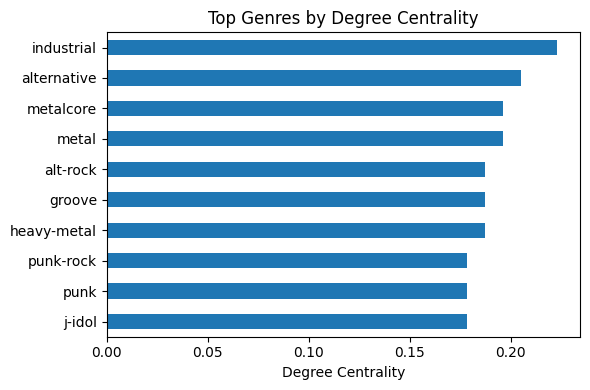

In [43]:
import matplotlib.pyplot as plt

degree_series = pd.Series(degree_centrality)

top_degree = degree_series.sort_values(ascending=False).head(10)

plt.figure(figsize=(6,4))
top_degree.sort_values().plot(kind="barh")

plt.xlabel("Degree Centrality")
plt.title("Top Genres by Degree Centrality")

plt.tight_layout()
plt.savefig("../outputs/degree_centrality.png", dpi=300)
plt.show()

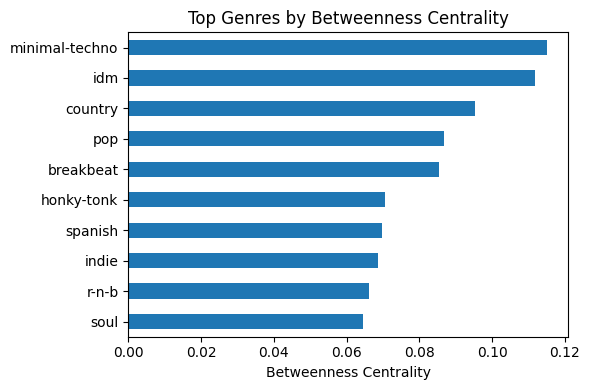

In [ ]:
betweenness_series = pd.Series(betweenness)

top_between = betweenness_series.sort_values(ascending=False).head(10)

plt.figure(figsize=(6,4))
top_between.sort_values().plot(kind="barh")

plt.xlabel("Betweenness Centrality")
plt.title("Top Genres by Betweenness Centrality")

plt.tight_layout()
plt.savefig("../outputs/betweenness_centrality.png", dpi=300) #
plt.show()

In [45]:
avg_clustering = nx.average_clustering(G)

print("Average clustering coefficient:", round(avg_clustering, 4))

Average clustering coefficient: 0.6188


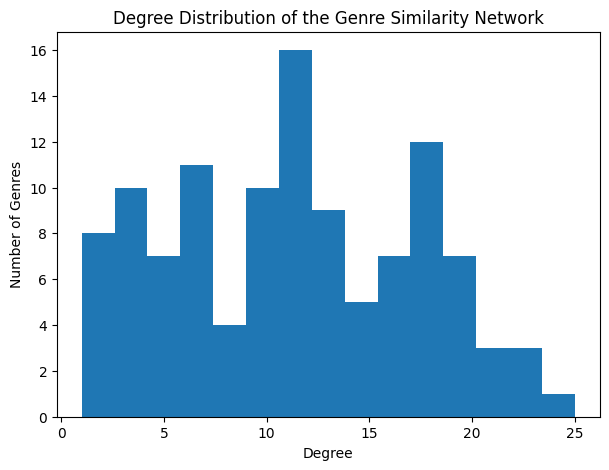

In [46]:
degrees = [d for n, d in G.degree()]

plt.figure(figsize=(7,5))

plt.hist(degrees, bins=15)

plt.xlabel("Degree")
plt.ylabel("Number of Genres")
plt.title("Degree Distribution of the Genre Similarity Network")

plt.show()

In [47]:
analysis_df.sort_values("popularity", ascending=False).head(10)

,degree,betweenness,clustering,popularity
pop-film,0.026786,0.000000,1.000000,59.283
k-pop,0.107143,0.015372,0.651515,56.896
chill,0.080357,0.016694,0.555556,53.651
sad,0.026786,0.007361,0.333333,52.379
grunge,0.169643,0.005012,0.725146,49.594
indian,0.107143,0.008209,0.606061,49.539
anime,0.017857,0.001076,0.000000,48.772
emo,0.044643,0.001880,0.700000,48.128
sertanejo,0.044643,0.010655,0.600000,47.866
pop,0.089286,0.086860,0.355556,47.576


In [48]:
thresholds = [0.6, 0.65, 0.7, 0.75, 0.8]

threshold_results = []

for threshold in thresholds:
    temp_G = nx.Graph()
    
    genres = similarity_df.index
    
    for i in range(len(genres)):
        for j in range(i + 1, len(genres)):
            g1 = genres[i]
            g2 = genres[j]
            sim = similarity_df.loc[g1, g2]
            
            if sim > threshold:
                temp_G.add_edge(g1, g2, weight=sim)
    
    num_nodes = temp_G.number_of_nodes()
    num_edges = temp_G.number_of_edges()
    density = nx.density(temp_G) if num_nodes > 1 else 0
    avg_degree = sum(dict(temp_G.degree()).values()) / num_nodes if num_nodes > 0 else 0
    num_components = nx.number_connected_components(temp_G) if num_nodes > 0 else 0
    
    components = list(nx.connected_components(temp_G)) if num_nodes > 0 else []
    largest_component_size = max(len(c) for c in components) if components else 0
    
    threshold_results.append({
        "threshold": threshold,
        "nodes": num_nodes,
        "edges": num_edges,
        "density": round(density, 4),
        "avg_degree": round(avg_degree, 2),
        "components": num_components,
        "largest_component": largest_component_size
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold,nodes,edges,density,avg_degree,components,largest_component
0,0.60,114,993,0.1542,17.42,1,114
1,0.65,114,805,0.1250,14.12,1,114
2,0.70,113,636,0.1005,11.26,2,110
3,0.75,111,496,0.0812,8.94,3,106
4,0.80,108,352,0.0609,6.52,4,99


# Codes after review

In [3]:
print(df.columns.tolist())

['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [ ]:
import pandas as pd
import networkx as nx

df = pd.read_csv("../data/dataset.csv")
G = nx.read_gexf("../gephi/genre_network_fixed_communities.gexf")

all_genres = set(df["track_genre"].unique())
graph_genres = set(G.nodes())

missing = all_genres - graph_genres

print("All genres:", len(all_genres))
print("Graph genres:", len(graph_genres))
print("Missing genres:", missing)
print("Count:", len(missing))

All genres: 114
Graph genres: 113
Missing genres: {'comedy'}
Count: 1
